# HW 6

We derive finite difference formulas by interpolating with a polynomial, then differentiating the interpolant. This leads to, for example, the formulas
\begin{align}
   W_1(h) &=  \frac{f(h)-f(0)}{h} = f'(0) + O(h), \\
   W_2(h) &=  \frac{f(h)-f(-h)}{2h} = f'(0) + O(h^2), \\
   W_4(h) &=  \frac{-f(2h) + 8f(h)-8f(-h)+f(-2h)}{12h} = f'(0) + O(h^4).
\end{align}
The terms $O(h^p)$ are a statement about the accuracy of the formula, which we say has order $p$.

However, interpolation by a polynomial isn't ideal for every $f$ you might encounter. One reason is that polynomials are smooth---they have infinitely many derivatives. Consider $f(x)=|x|$, for example. It's continuous but not differentiable at $x=0$. What value should the finite difference attempt to get there: $+1$, $-1$, or something else? For a function that has one derivative but not two, there is a unique value to converge to, but the convergence rate is slowed by the singularity. 

You will apply finite difference methods of different orders to functions that lack smoothness at a point, and observe the effects on the order of accuracy.

\emph{Preparation:} Determine the number of continuous derivatives at $x=0$ for the following functions:
\begin{align}
  g_1(x) =
  \begin{cases}
    5x+1, & x \le 0 \\ (x+1)^5, & x > 0
  \end{cases} \\
  g_2(x) =
  \begin{cases}
    10x^2 + 5\sin(x) + 1, & x \le 0 \\ (x+1)^5, & x>0
  \end{cases}
\end{align}

### (a)

Define $f(x)=\exp(\sin(x+1))$. This is our "control'' case of a function with infinitely many derivatives everywhere. For each value of $h=2^{-1},2^{-2},2^{-3},\ldots,2^{-10}$, compute $W_1(h)$, $W_2(h)$, and $W_4(h)$, storing the results in vectors. Then make a log-log plot showing all three cases of $|W_i(h)-f'(0)|$ as functions of $h$. You should see three straight lines with different slopes.

In [3]:
# test function
f(x) = exp(sin(x+1))
f_prime(x) = f(x)*cos(x+1)

# define derivative approximations
function W1(h, f, x = 0)
    return (f(x+h) - f(x))/h
end

function W2(h, f, x = 0)
    return (f(x+h) - f(x-h))/(2h)
end

function W4(h, f, x = 0)
    return (f(x-2h) - 8f(x-h) + 8f(x+h) - f(x+2h))/(12h)
end

W4 (generic function with 2 methods)

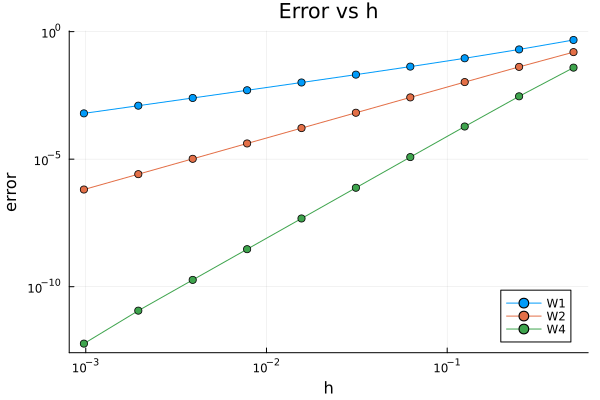

In [9]:
using Plots

h_list = [2.0^(-i) for i in 1:10]

# compute the derivatives
W1_list = [W1(h, f) for h in h_list]
W2_list = [W2(h, f) for h in h_list]
W4_list = [W4(h, f) for h in h_list]

# compute the errors
error_W1 = [abs(W1 - f_prime(0)) for W1 in W1_list]
error_W2 = [abs(W2 - f_prime(0)) for W2 in W2_list]
error_W4 = [abs(W4 - f_prime(0)) for W4 in W4_list]

# plot h vs error
plot(h_list, error_W1, label="W1", xaxis=:log, yaxis=:log, xlabel="h", ylabel="error", title="Error vs h", marker=:circle, legend=:bottomright)
plot!(h_list, error_W2, label="W2", marker=:circle)
plot!(h_list, error_W4, label="W4", marker=:circle)

### (b)

To the graph from step 1, add plots of the functions $h^1$, $h^2$, $h^3$, and $h^4$, as dashed lines. (Use labels, legends, etc.)  Confirm that each solid convergence curve matches well with the dashed line corresponding to the order of accuracy in the presentation of the formulas above.

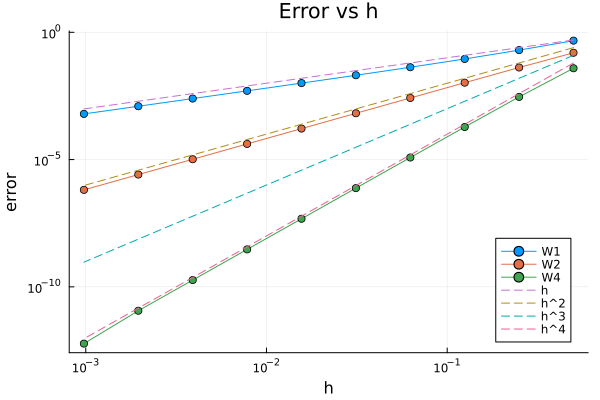

In [10]:
h2_list = [h^2 for h in h_list]
h3_list = [h^3 for h in h_list]
h4_list = [h^4 for h in h_list]

# add the curves to plot
plot!(h_list, h_list, label="h", linestyle=:dash)
plot!(h_list, h2_list, label="h^2", linestyle=:dash)
plot!(h_list, h3_list, label="h^3", linestyle=:dash)
plot!(h_list, h4_list, label="h^4", linestyle=:dash)

### (c)

Now input $g_1$ from~\eqref{g1}, by defining 

```
g1 = x -> (5*x+1).*(x<=0) + ((x+1).^5).*(x>0);
```

(This defines the function piecewise for negative and positive $x$.) Make a plot of the function over $[-1/4,1/4]$.

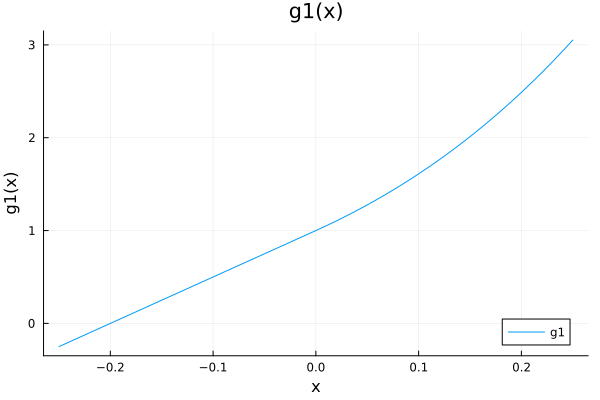

In [12]:
g1 = x -> (5*x+1).*(x<=0) + ((x+1).^5).*(x>0)

# plot function over [-1/4, 1/4]
plot(-1/4:0.01:1/4, g1.(-1/4:0.01:1/4), label="g1", xlabel="x", ylabel="g1(x)", title="g1(x)", legend=:bottomright)

### (d)

Repeat steps (a)--(b) for the function in step (c). Now what are the observed orders of accuracy for $W_1$, $W_2$, and $W_4$?

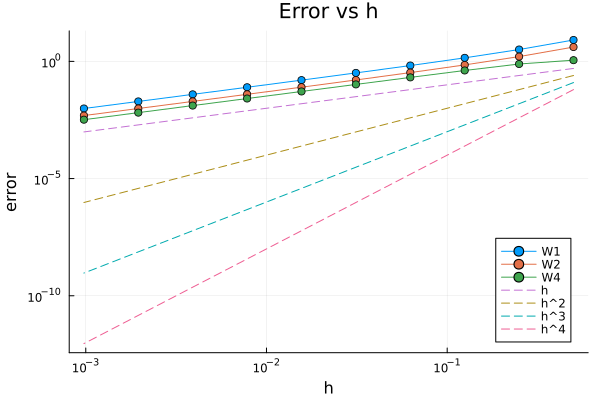

In [13]:
# compute the derivatives
W1_list = [W1(h, g1) for h in h_list]
W2_list = [W2(h, g1) for h in h_list]
W4_list = [W4(h, g1) for h in h_list]

# compute the errors
error_W1 = [abs(W1 - 5) for W1 in W1_list]
error_W2 = [abs(W2 - 5) for W2 in W2_list]
error_W4 = [abs(W4 - 5) for W4 in W4_list]

# plot h vs error
plot(h_list, error_W1, label="W1", xaxis=:log, yaxis=:log, xlabel="h", ylabel="error", title="Error vs h", marker=:circle, legend=:bottomright)
plot!(h_list, error_W2, label="W2", marker=:circle)
plot!(h_list, error_W4, label="W4", marker=:circle)
plot!(h_list, h_list, label="h", linestyle=:dash)
plot!(h_list, h2_list, label="h^2", linestyle=:dash)
plot!(h_list, h3_list, label="h^3", linestyle=:dash)
plot!(h_list, h4_list, label="h^4", linestyle=:dash)

The results are clearly different! Every curve roughly follows the slope of $h$.

### (e)

Repeat steps (a)--(b) for the function $g_2$.

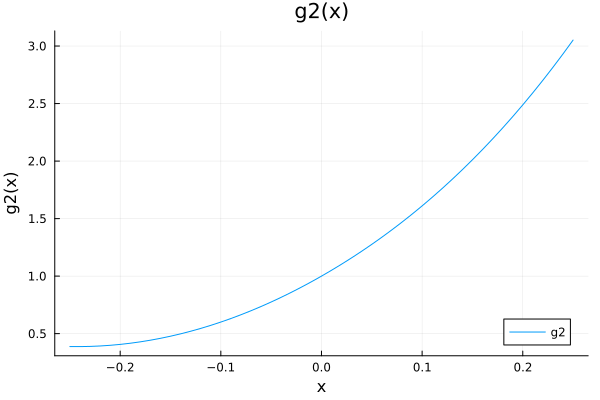

In [16]:
g2 = x -> (10*x^2+5*sin.(x)+1).*(x<=0) + ((x+1).^5).*(x>0)
plot(-1/4:0.01:1/4, g2.(-1/4:0.01:1/4), label="g2", xlabel="x", ylabel="g2(x)", title="g2(x)", legend=:bottomright)

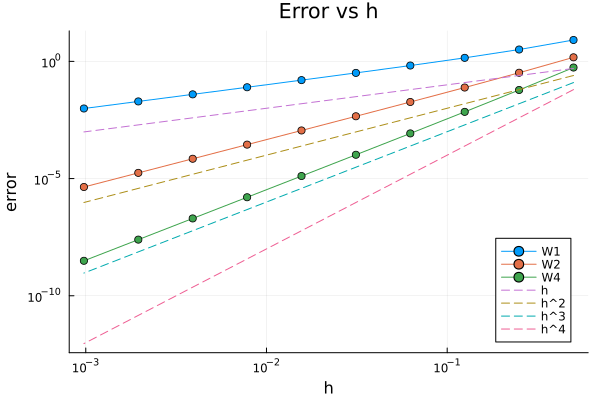

In [17]:
# compute the derivatives
W1_list = [W1(h, g2) for h in h_list]
W2_list = [W2(h, g2) for h in h_list]
W4_list = [W4(h, g2) for h in h_list]

# compute the errors
error_W1 = [abs(W1 - 5) for W1 in W1_list]
error_W2 = [abs(W2 - 5) for W2 in W2_list]
error_W4 = [abs(W4 - 5) for W4 in W4_list]

# plot h vs error
plot(h_list, error_W1, label="W1", xaxis=:log, yaxis=:log, xlabel="h", ylabel="error", title="Error vs h", marker=:circle, legend=:bottomright)
plot!(h_list, error_W2, label="W2", marker=:circle)
plot!(h_list, error_W4, label="W4", marker=:circle)
plot!(h_list, h_list, label="h", linestyle=:dash)
plot!(h_list, h2_list, label="h^2", linestyle=:dash)
plot!(h_list, h3_list, label="h^3", linestyle=:dash)
plot!(h_list, h4_list, label="h^4", linestyle=:dash)

Notice that the slopes of $W_1$ and $W_2$ match $h$ and $h^2$, but the slope of $W_4$ matches that of $h^3$!

### (f)

What number of continuous derivatives does $g_1$ and $g_2$ have?

---

For $g_1$, we know that $\frac{d}{dx} \big( 5x + 1\big) \big|_{x=0} = \frac{d}{dx} \big( (x+1)^5 \big) \big|_{x=0} = 5$, but $\frac{d^2}{dx^2} \big( 5x+1 \big) \big|_{x=0} = 0$ while $\frac{d^2}{dx^2} \big( (x+1)^5 \big) \big|_{x=0} = 20$. So $g_1$ has 1 continuous derivative.

For $g_2$, we know that $\frac{d}{dx} \big( 10x^2 + 5 \sin(x) + 1 \big) \big|_{x=0} = \frac{d}{dx} \big( (x+1)^5 \big) \big|_{x=0} = 5$, $\frac{d^2}{dx^2} \big( 10x^2 + 5 \sin(x) + 1 \big) \big|_{x=0} =\frac{d^2}{dx^2} \big( (x+1)^5 \big) \big|_{x=0} = 20$, $\frac{d^3}{dx^3} \big( 10x^2 + 5 \sin(x) + 1 \big) \big|_{x=0} = -5$ while $\frac{d^3}{dx^3} \big( (x+1)^5 \big) \big|_{x=0} = 60$. So $g_2$ has 2 continuous derivatives.

### (g)

Hypothesize how the number of continuous derivatives of the input function affects the order of accuracy of finite difference methods.  Comment on how your hypothesis is corroborated by the three convergence plots created above.

---

My hypothesis is that

$$
\text{slope} \sim \begin{cases}
< p \quad & p > n \\
= p \quad & p \leq n
\end{cases}
$$

$p$ being the order of the finite difference formula and $n$ being the number of continuous derivatives the function has. For $f$, $n$ is infinite and so the slope is equal to the order. For $g_1$, $n$ is 1 and so the slope is capped at 1. Similarly, for $g_2$, $n$ is 2 so when the order is less than or equal to 2 the slope matches but when the order goes above 2, the slope is constrained from above.

In summary, more degrees of continuity, more accuracy.